In [1]:
import polars as pl
import numpy as np

In [2]:
df = pl.read_parquet("../transactions-2025-12.parquet")

print(len(df))
df.head(10)

3782447


customer_id,item_id,price,channel,payment,updated_date,location,quantity
i32,str,"decimal[38,4]",str,str,datetime[μs],i32,i32
8861340,"""0151000000003""",1625000.0000,"""In-Store""","""Tiền mặt""",2025-12-12 16:44:47.793,385,1
8680587,"""5074000000001""",139000.0000,"""SPE""","""Tiền mặt""",2025-12-01 10:28:50.830,1063,1
8220170,"""5856000000001""",480000.0000,"""SPE""","""Tiền mặt""",2025-12-23 09:20:27.653,416,1
7496264,"""6768000000002""",316200.0000,"""SPE""","""Tiền mặt""",2025-12-23 09:06:39.980,336,3
9170522,"""6904000000002""",840000.0000,"""SPE""","""Không xác định""",2025-12-23 09:24:55.640,601,1
7475624,"""4652000000002""",237000.0000,"""SPE""","""Không xác định""",2025-12-30 13:16:55.897,829,1
7211525,"""2231000000028""",347000.0000,"""In-Store""","""VietQR""",2025-12-09 10:40:31.090,1123,3
9154514,"""0020010000301""",460000.0000,"""SPE""","""Không xác định""",2025-12-16 12:13:19.373,96,2
3818301,"""6766000000002""",156980.0000,"""SPE""","""Tiền mặt""",2025-12-16 12:14:31.373,1230,1


In [3]:
print(df.select(pl.col("item_id").n_unique()))
print(df.select(pl.col("location").n_unique()))

shape: (1, 1)
┌─────────┐
│ item_id │
│ ---     │
│ u32     │
╞═════════╡
│ 13544   │
└─────────┘
shape: (1, 1)
┌──────────┐
│ location │
│ ---      │
│ u32      │
╞══════════╡
│ 1005     │
└──────────┘


# lọc theo location và item id

In [4]:
df = pl.read_parquet("../transactions-2025-12.parquet")

result = (
    df.group_by(["item_id", "location"])
      .agg(pl.len().alias("count"))
)

print(result)
n=len(result)
print(n)

shape: (1_167_571, 3)
┌───────────────┬──────────┬───────┐
│ item_id       ┆ location ┆ count │
│ ---           ┆ ---      ┆ ---   │
│ str           ┆ i32      ┆ u32   │
╞═══════════════╪══════════╪═══════╡
│ 5477000000003 ┆ 771      ┆ 2     │
│ 2019000000006 ┆ 744      ┆ 1     │
│ 3389000000191 ┆ 545      ┆ 1     │
│ 7450000000001 ┆ 118      ┆ 1     │
│ 6768000000009 ┆ 333      ┆ 15    │
│ …             ┆ …        ┆ …     │
│ 2110000000018 ┆ 705      ┆ 1     │
│ 0007380000040 ┆ 836      ┆ 1     │
│ 0029120000028 ┆ 278      ┆ 3     │
│ 0042000000007 ┆ 1071     ┆ 1     │
│ 4684000000003 ┆ 650      ┆ 5     │
└───────────────┴──────────┴───────┘
1167571


# random 1 cặp bất kỳ

In [5]:
random_pair = result.sample(1)

print(random_pair)
item = random_pair["item_id"][0]
loc = random_pair["location"][0]

rows = df.filter(
    (pl.col("item_id") == item) &
    (pl.col("location") == loc)
).select(["item_id", "updated_date","quantity", "location"])

print(rows)

shape: (1, 3)
┌───────────────┬──────────┬───────┐
│ item_id       ┆ location ┆ count │
│ ---           ┆ ---      ┆ ---   │
│ str           ┆ i32      ┆ u32   │
╞═══════════════╪══════════╪═══════╡
│ 2403000000002 ┆ 789      ┆ 3     │
└───────────────┴──────────┴───────┘
shape: (3, 4)
┌───────────────┬─────────────────────────┬──────────┬──────────┐
│ item_id       ┆ updated_date            ┆ quantity ┆ location │
│ ---           ┆ ---                     ┆ ---      ┆ ---      │
│ str           ┆ datetime[μs]            ┆ i32      ┆ i32      │
╞═══════════════╪═════════════════════════╪══════════╪══════════╡
│ 2403000000002 ┆ 2025-12-07 18:01:25.843 ┆ 1        ┆ 789      │
│ 2403000000002 ┆ 2025-12-29 15:15:28.763 ┆ 1        ┆ 789      │
│ 2403000000002 ┆ 2025-12-25 13:41:56.263 ┆ 1        ┆ 789      │
└───────────────┴─────────────────────────┴──────────┴──────────┘


# transform

In [6]:
import polars as pl

# 1. Thêm cột day từ updated_date
df_day = df.with_columns(
    pl.col("updated_date").dt.day().alias("day")
)

# 2. Tạo cột 'week' dựa trên các mốc ngày (dùng when...then)
df_week_mapped = df_day.with_columns(
    pl.when(pl.col("day") <= 7).then(1)
    .when(pl.col("day") <= 14).then(2)
    .when(pl.col("day") <= 21).then(3)
    .otherwise(4)
    .alias("week")
)

# 3. Gom nhóm theo location, item_id và week để tính tổng quantity
df_final = (
    df_week_mapped
    .group_by(["location", "item_id", "week"])
    .agg(
        pl.col("quantity").sum().alias("total_quantity")
    )
    .sort(["location", "item_id", "week"]) # Sắp xếp lại cho dễ nhìn
)

print(df_final.head(20))

shape: (20, 4)
┌──────────┬───────────────┬──────┬────────────────┐
│ location ┆ item_id       ┆ week ┆ total_quantity │
│ ---      ┆ ---           ┆ ---  ┆ ---            │
│ i32      ┆ str           ┆ i32  ┆ i32            │
╞══════════╪═══════════════╪══════╪════════════════╡
│ 42       ┆ 0000280000138 ┆ 3    ┆ 1              │
│ 42       ┆ 0004104000002 ┆ 4    ┆ 1              │
│ 42       ┆ 0006020000278 ┆ 4    ┆ 1              │
│ 42       ┆ 0006020000279 ┆ 2    ┆ 1              │
│ 42       ┆ 0006030000026 ┆ 2    ┆ 1              │
│ …        ┆ …             ┆ …    ┆ …              │
│ 42       ┆ 0006040000303 ┆ 2    ┆ 3              │
│ 42       ┆ 0006040000303 ┆ 4    ┆ 1              │
│ 42       ┆ 0006040000317 ┆ 4    ┆ 1              │
│ 42       ┆ 0006040000318 ┆ 4    ┆ 2              │
│ 42       ┆ 0006040000433 ┆ 2    ┆ 1              │
└──────────┴───────────────┴──────┴────────────────┘


# train test split

In [7]:
from datetime import datetime


train = df_final.filter(pl.col("week") <= 3)
test  = df_final.filter(pl.col("week") >= 4)

print("train size:", len(train))
print("test size:", len(test))

train size: 1509909
test size: 627813


In [8]:
print(len(df_final))

2137722


# ve matplotlib

In [9]:
import matplotlib.pyplot as plt
def visualize(df_final, model):
    # 1. Tìm các cặp (location, item_id) xuất hiện đủ 4 lần (tương ứng 4 tuần)
    valid_pairs = (
        df_final
        .group_by(["location", "item_id"])
        .agg(pl.len().alias("week_count"))
        .filter(pl.col("week_count") == 4)
        .sort(["location", "item_id"])
    )

    # Kiểm tra xem có cặp nào đủ 4 tuần không
    if valid_pairs.height == 0:
        print("Không có cặp location và item_id nào xuất hiện đủ 4 tuần!")
    else:
        # 2. Lấy ngẫu nhiên 1 cặp
        random_pair = valid_pairs.sample(n=1, seed=72)
        rand_loc = random_pair["location"][0]
        rand_item = random_pair["item_id"][0]

        # 3. Lọc lấy data của riêng cặp này từ df_final
        plot_data = df_final.filter(
            (pl.col("location") == rand_loc) & 
            (pl.col("item_id") == rand_item)
        ).sort("week")

        # Chuyển đổi cột Polars sang list để đưa vào matplotlib
        x_weeks = plot_data["week"].to_list()
        y_quantities = plot_data["total_quantity"].to_list()

        # 4. Vẽ biểu đồ đường (Line chart)
        plt.figure(figsize=(8, 5))
        plt.scatter(x_weeks, y_quantities, marker='o', color='red', linestyle='-', linewidth=2)
        
        for i, value in enumerate(y_quantities):
            plt.annotate(
                str(value),                    # Giá trị cần hiển thị
                (x_weeks[i], y_quantities[i]), # Tọa độ x, y của điểm
                textcoords="offset points",    # Cách tính offset
                xytext=(0, 10),                # Dịch lên trên điểm 10 point để không bị đè lên chấm tròn
                ha='center',                   # Căn giữa chữ
                fontsize=10,
                fontweight='bold',
                color='blue'                   # Màu chữ
            )

        # Trang trí biểu đồ
        plt.title(f"Xu hướng bán hàng\nLocation: {rand_loc} | Item ID: {rand_item}", fontweight='bold')
        plt.xlabel("Week")
        plt.ylabel("Total Quantity")
        plt.xticks([1, 2, 3, 4]) # Ép trục X chỉ hiện thị số nguyên 1, 2, 3, 4
        plt.grid(True, linestyle='--', alpha=0.6)
        
        if model is not None:
                x_line = np.linspace(1, 5, 100)
    
                # Tính Y dựa trên trọng số (coef_) và độ lệch (intercept_) của Linear Regression
                y_line = model.coef_[0] * x_line + model.intercept_
                
                # Vẽ đường thẳng mô hình
                plt.plot(x_line, y_line, color='blue', linestyle='-', linewidth=2, zorder=2, label='Đường xu hướng (Mô hình)')
                # ==========================================

                # 3. Trang trí biểu đồ
                plt.title(f"Thực tế vs Mô hình dự đoán", fontweight='bold')
                plt.xlabel("Week")
                plt.ylabel("Total Quantity")
                plt.xticks([1, 2, 3, 4]) 
                
                # Thêm chú thích (Legend) để phân biệt chấm đỏ và đường xanh
                plt.legend(loc="best")
                
                plt.grid(True, linestyle='--', alpha=0.6, zorder=1)
                plt.margins(y=0.2) 

        # Hiển thị
        plt.show()

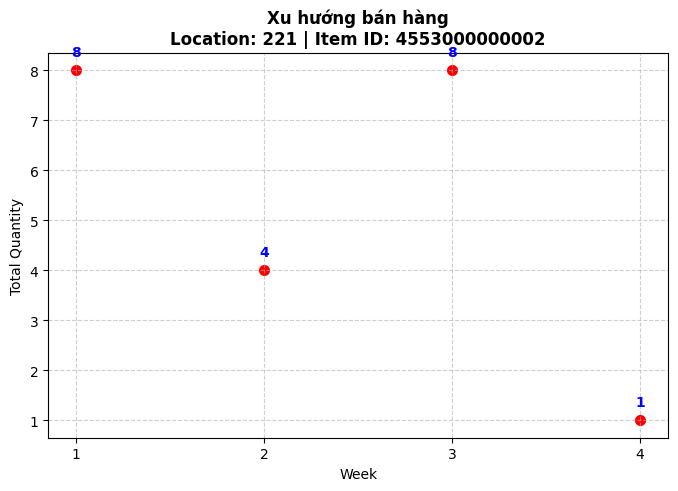

In [10]:
visualize(df_final, None)

# train mo hinh

In [11]:
X_train = train['week'].to_numpy().reshape(-1,1)
y_train=train['total_quantity']
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)
print(model.coef_, model.intercept_)

[-0.07924161] 2.9906261086033012


# Predict

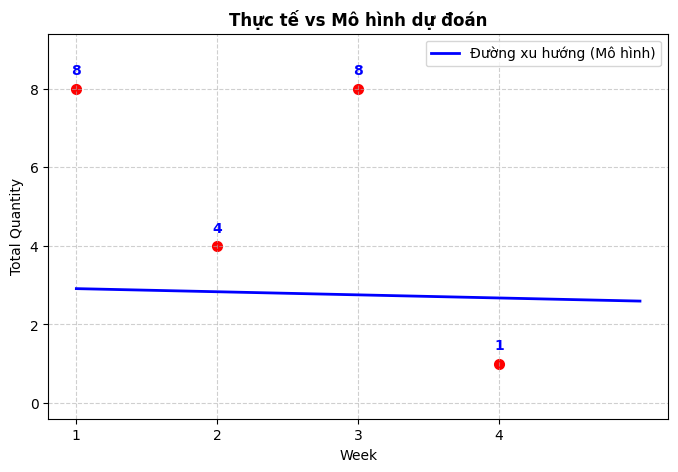

In [12]:
visualize(df_final, model)

In [13]:
from sklearn.metrics import mean_squared_error
X_test = test["week"].to_numpy().reshape(-1,1)
y_test=test['total_quantity']
y_pred=model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 52.13751290343439


In [14]:
import pickle
filename='modelB.pkl'
pickle.dump(model, open('modelB.pkl', 'wb'))